# **Section 13.5 – The Binomial Theorem with Pascal's Triangle**

## Objectives

How would you expand $(x+2)^6$? Multiplying $(x+2)$ by itself six times is slow and easy to get wrong. The **Binomial Theorem** gives every term of $(a+b)^n$ directly, and **Pascal's Triangle** gives the numbers in front of each term (the **coefficients**).

These same numbers count **combinations**: the number of ways to choose $k$ items from $n$. That is why they appear throughout probability, statistics, and data science.

By the end of this assignment you should be comfortable expanding binomials and finding any single term without expanding everything.

# Learning Objectives

After completing this reading assignment you should be able to:

1. Build Pascal's Triangle and read any row.
2. Compute binomial coefficients $\binom{n}{k}$ with factorials.
3. State the Binomial Theorem.
4. Expand $(a+b)^n$, including binomials with coefficients and negative terms.
5. Find a specific term or coefficient without expanding everything.
6. Explain why each row of Pascal's Triangle adds up to $2^n$.
7. Connect binomial coefficients to probability and data science.

In [ ]:
## You need to run this code only once
%pip install -q --upgrade "git+https://github.com/c3adsNcat/InteractiveNotebook.git"

# Interactive feedback helper package
from math_interactive.math131 import check_answer, check_code_answer
import math


## 1. Looking for a Pattern

Here are the first few powers of $(a+b)$:

$$
\begin{aligned}
(a+b)^0 &= 1 \\
(a+b)^1 &= a + b \\
(a+b)^2 &= a^2 + 2ab + b^2 \\
(a+b)^3 &= a^3 + 3a^2b + 3ab^2 + b^3 \\
(a+b)^4 &= a^4 + 4a^3b + 6a^2b^2 + 4ab^3 + b^4
\end{aligned}
$$

Three patterns appear in every expansion of $(a+b)^n$:

- There are $n + 1$ terms.
- The power of $a$ **starts at $n$ and goes down by 1**; the power of $b$ **starts at $0$ and goes up by 1**.
- In every term, the powers add up to $n$.

The coefficients $1,\ 4,\ 6,\ 4,\ 1$ come from **Pascal's Triangle**.

## 2. Pascal's Triangle

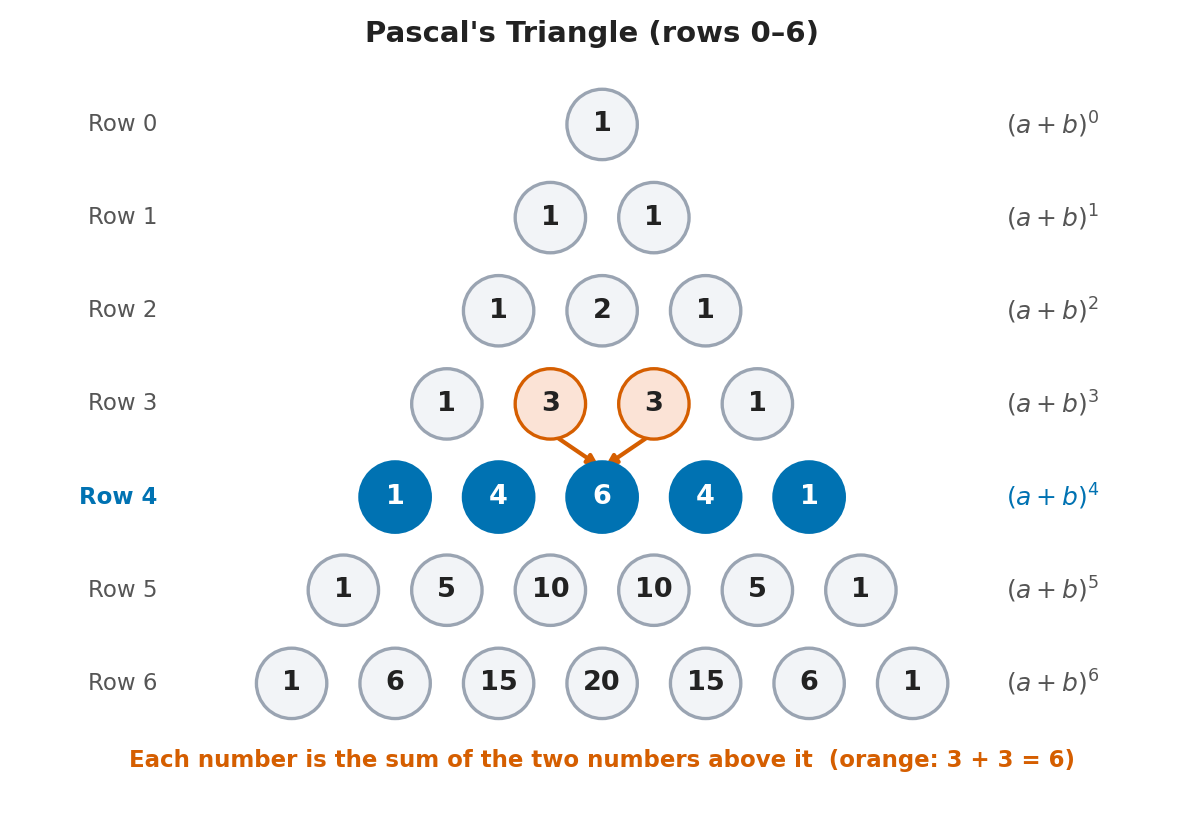

### Description

The image shows **Pascal's Triangle** from row 0 to row 6, arranged as a triangle of numbered circles.

- **Row 0** at the top has a single $1$. Each row below has one more number than the row above it.
- Every row **starts and ends with $1$**.
- Each number inside the triangle is the **sum of the two numbers directly above it**. The two orange circles in row 3 ($3$ and $3$) have arrows pointing to the $6$ below them, because $3 + 3 = 6$.
- **Row 4** is highlighted in blue: $1,\ 4,\ 6,\ 4,\ 1$. These are the coefficients of $(a+b)^4$, shown on the right side of that row.
- The label on the right of each row shows which power of $(a+b)$ the row belongs to, from $(a+b)^0$ to $(a+b)^6$.
- The triangle is **symmetric**: each row reads the same forwards and backwards, for example $1,\ 6,\ 15,\ 20,\ 15,\ 6,\ 1$.

**Important:** row numbering starts at **0**, so row $n$ gives the coefficients of $(a+b)^n$.

### Example 1 (Building a Row)

Use row 4 ($1,\ 4,\ 6,\ 4,\ 1$) to build row 5.

Start and end with $1$, and add each pair of neighbors:

$$1,\quad 1+4=5,\quad 4+6=10,\quad 6+4=10,\quad 4+1=5,\quad 1$$

**Row 5:** $1,\ 5,\ 10,\ 10,\ 5,\ 1$

**Explanation**

Row 5 has six numbers, which matches the six terms of $(a+b)^5$.

### ✏️ Question 1: Reading Pascal's Triangle

Which list gives the coefficients of $(a+b)^5$?

A. $1,\ 4,\ 6,\ 4,\ 1$

B. $1,\ 5,\ 10,\ 10,\ 5,\ 1$

C. $1,\ 5,\ 10,\ 5,\ 1$

D. $1,\ 6,\ 15,\ 20,\ 15,\ 6,\ 1$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q7_final = ""
check_answer("q7", q7_final)

### BEGIN SOLUTION
q7_final = "B"
check_answer("q7", q7_final)
### END SOLUTION


## 3. Binomial Coefficients

For large $n$, drawing the triangle takes too long. Each entry can be computed directly with **factorials**.

**Factorial:** $n! = n \cdot (n-1) \cdot (n-2) \cdots 2 \cdot 1$, and $0! = 1$.

**Binomial coefficient** (read "$n$ choose $k$"):

$$\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$$

$\binom{n}{k}$ is entry number $k$ in row $n$ of Pascal's Triangle (counting from $0$).

### Example 2 (Computing $\binom{n}{k}$)

$$\binom{5}{2} = \frac{5!}{2!\,3!} = \frac{120}{2 \cdot 6} = 10$$

**Explanation**

Check the triangle: row 5 is $1,\ 5,\ \mathbf{10},\ 10,\ 5,\ 1$, and entry number 2 (counting $1$ as entry $0$) is $10$. ✓

*Shortcut:* cancel before multiplying. $\dfrac{5!}{2!\,3!} = \dfrac{5 \cdot 4}{2 \cdot 1} = 10$.

### ✏️ Question 2: Computing a Binomial Coefficient

Find

$$
\binom{7}{3}
$$

A. $21$

B. $210$

C. $35$

D. $7$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q8_final = ""
check_answer("q8", q8_final)

### BEGIN SOLUTION
q8_final = "C"
check_answer("q8", q8_final)
### END SOLUTION


## 4. The Binomial Theorem

$$
(a+b)^n = \binom{n}{0}a^n + \binom{n}{1}a^{n-1}b + \binom{n}{2}a^{n-2}b^2 + \cdots + \binom{n}{n}b^n
$$

In short, $(a+b)^n = \displaystyle\sum_{k=0}^{n} \binom{n}{k} a^{n-k} b^k$.

### General Procedure

1. Identify $a$, $b$, and $n$. Keep any sign with $b$ (for $x - 2$, $b = -2$).
2. Get the coefficients from row $n$ of Pascal's Triangle (or from $\binom{n}{k}$).
3. Write the powers: $a$ goes **down** from $n$ to $0$, $b$ goes **up** from $0$ to $n$.
4. Multiply everything out in each term, **including the numbers inside $a$ and $b$**.
5. Simplify and check: there should be $n+1$ terms.

### Example 3 (Basic Expansion)

Expand $(x+y)^3$.

Row 3: $1,\ 3,\ 3,\ 1$

$$(x+y)^3 = 1x^3 + 3x^2y + 3xy^2 + 1y^3 = x^3 + 3x^2y + 3xy^2 + y^3$$

**Explanation**

The powers of $x$ go $3, 2, 1, 0$ and the powers of $y$ go $0, 1, 2, 3$.

### ✏️ Question 3: Expanding a Binomial

Expand

$$
(x+1)^4
$$

A. $x^4 + 4x^3 + 6x^2 + 4x + 1$

B. $x^4 + 1$

C. $x^4 + 4x^3 + 4x^2 + 4x + 1$

D. $x^4 + 3x^3 + 3x^2 + x + 1$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q9_final = ""
check_answer("q9", q9_final)

### BEGIN SOLUTION
q9_final = "A"
check_answer("q9", q9_final)
### END SOLUTION


### Example 4 (Binomial with Numbers)

Expand $(2x+1)^3$. Here $a = 2x$, $b = 1$, and row 3 is $1,\ 3,\ 3,\ 1$.

$$
\begin{aligned}
(2x+1)^3 &= 1(2x)^3 + 3(2x)^2(1) + 3(2x)(1)^2 + 1(1)^3 \\
&= 8x^3 + 12x^2 + 6x + 1
\end{aligned}
$$

**Finding one coefficient:** in $(x+2)^4$, the $x^2$ term uses $\binom{4}{2}$ and $b^2$:

$$\binom{4}{2}x^2(2)^2 = 6 \cdot 4 \cdot x^2 = 24x^2$$

**Explanation**

The number inside the parentheses gets raised to a power too: $(2x)^3 = 8x^3$, **not** $2x^3$.

### ✏️ Question 4: Finding a Coefficient

What is the coefficient of $x^2$ in the expansion of

$$
(x+3)^4 \;?
$$

A. $6$

B. $18$

C. $81$

D. $54$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q10_final = ""
check_answer("q10", q10_final)

### BEGIN SOLUTION
q10_final = "D"
check_answer("q10", q10_final)
### END SOLUTION


### Example 5 (Negative Term)

Expand $(x-2)^3$. Write it as $(x + (-2))^3$, so $b = -2$.

$$
\begin{aligned}
(x-2)^3 &= x^3 + 3x^2(-2) + 3x(-2)^2 + (-2)^3 \\
&= x^3 - 6x^2 + 12x - 8
\end{aligned}
$$

**Explanation**

When $b$ is negative, the signs **alternate**: $+,\ -,\ +,\ -$. Odd powers of a negative number are negative; even powers are positive.

### ✏️ Question 5: Binomial with a Negative Term

Expand

$$
(x-1)^3
$$

A. $x^3 + 3x^2 + 3x + 1$

B. $x^3 - 3x^2 + 3x - 1$

C. $x^3 - 3x^2 - 3x - 1$

D. $x^3 - 1$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q11_final = ""
check_answer("q11", q11_final)

### BEGIN SOLUTION
q11_final = "B"
check_answer("q11", q11_final)
### END SOLUTION


## 5. Finding a Specific Term

The $(k+1)$**st term** of $(a+b)^n$ is

$$\binom{n}{k}a^{n-k}b^k$$

The term number is **one more** than $k$, because counting starts at $k = 0$.

### Example 6

Find the **4th term** of $(x+2)^6$.

4th term $\Rightarrow k = 3$:

$$\binom{6}{3}x^{3}(2)^3 = 20 \cdot x^3 \cdot 8 = 160x^3$$

**Explanation**

A common mistake is using $k = 4$ for the 4th term. Remember: 1st term $\to k=0$, 2nd term $\to k=1$, and so on.

### ✏️ Question 6: Finding a Specific Term

Find the **3rd term** in the expansion of

$$
(x+3)^5
$$

A. $10x^3$

B. $30x^3$

C. $90x^3$

D. $270x^2$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q12_final = ""
check_answer("q12", q12_final)

### BEGIN SOLUTION
q12_final = "C"
check_answer("q12", q12_final)
### END SOLUTION


## 6. Row Sums

Add up each row of Pascal's Triangle:

| Row n | Entries | Sum |
|:---:|:---|:---|
| 0 | 1 | 1 = 2⁰ |
| 1 | 1, 1 | 2 = 2¹ |
| 2 | 1, 2, 1 | 4 = 2² |
| 3 | 1, 3, 3, 1 | 8 = 2³ |
| 4 | 1, 4, 6, 4, 1 | 16 = 2⁴ |

### Example 7

Why is the sum of row $n$ equal to $2^n$? Put $a = 1$ and $b = 1$ into the Binomial Theorem:

$$(1+1)^n = \binom{n}{0} + \binom{n}{1} + \cdots + \binom{n}{n} \quad\Longrightarrow\quad 2^n = \text{sum of row } n$$

**Explanation**

So the **sum of the coefficients** of $(x+y)^n$ is always $2^n$.

### ✏️ Question 7: Sum of the Coefficients

What is the sum of all the coefficients in the expansion of

$$
(x+y)^6 \;?
$$

A. $64$

B. $36$

C. $20$

D. $128$

In [ ]:
# Final answer for grading: enter "A", "B", "C", or "D".
q13_final = ""
check_answer("q13", q13_final)

### BEGIN SOLUTION
q13_final = "A"
check_answer("q13", q13_final)
### END SOLUTION


# Common Mistakes

- Starting row numbers at $1$ instead of $0$.
- Using $k = 4$ for the 4th term (it should be $k = 3$).
- Forgetting to raise the number inside the parentheses: $(2x)^3 = 8x^3$, not $2x^3$.
- Dropping the negative sign when $b$ is negative, so the signs don't alternate.
- Writing the powers in the wrong order, or making them not add up to $n$.
- Ending up with the wrong number of terms (it should be $n + 1$).

# Connecting to Data Science

Binomial coefficients **count choices**: $\binom{n}{k}$ is the number of ways to choose $k$ items from $n$. Data scientists use this idea constantly.

### 1. Probability of "yes/no" outcomes (the binomial distribution)

Many data questions have two outcomes per trial: a coin lands heads or tails, a customer clicks or doesn't, a part passes or fails inspection. If each trial succeeds with probability $p$, the probability of **exactly $k$ successes in $n$ trials** is

$$P(k) = \binom{n}{k}\,p^k\,(1-p)^{n-k}$$

This is exactly one term of the Binomial Theorem applied to $\big(p + (1-p)\big)^n = 1^n = 1$, which is why all the probabilities add up to $1$.

*Example:* flip a fair coin 4 times. The chance of **exactly 2 heads** is $\binom{4}{2}\left(\tfrac{1}{2}\right)^4 = \dfrac{6}{16} = 0.375$. Notice the $6$ comes straight from row 4 of Pascal's Triangle.

### 2. A/B testing

A company shows two versions of a web page to visitors and counts how many click. Binomial probabilities tell analysts whether a difference in clicks is **real** or could just be **random chance**.

### 3. Choosing features for a model

A dataset with $n$ columns (features) has $\binom{n}{k}$ ways to pick $k$ of them, and $2^n$ possible subsets in total. That is the row-sum result from Example 7. With $20$ features there are $2^{20} = 1{,}048{,}576$ subsets, which is why data scientists use smart search methods instead of trying every combination.

### 4. Polynomial features in machine learning

To let a model learn curves, data scientists create new features by expanding expressions like $(x_1 + x_2)^2 = x_1^2 + 2x_1x_2 + x_2^2$. The Binomial Theorem tells us which terms appear.

Run the cell below to see the coin-flip probabilities for 4 flips. Notice how the counts match row 4 of Pascal's Triangle.

In [ ]:
# Probability of k heads in 4 fair coin flips
import math

n = 4
for k in range(n + 1):
    ways = math.comb(n, k)          # entry k of row n in Pascal's Triangle
    prob = ways / 2**n              # each outcome has probability (1/2)^n
    print(f"{k} heads: {ways} way(s), probability = {prob:.4f}  " + "#" * ways)

### ✏️ Question 8: Build a Row of Pascal's Triangle in Code

Complete the function `pascal_row(n)` so that it **returns** row $n$ of Pascal's Triangle as a Python **list**.

For example:

- `pascal_row(2)` should return `[1, 2, 1]`
- `pascal_row(4)` should return `[1, 4, 6, 4, 1]`

*Hints:*
- `math.comb(n, k)` gives $\binom{n}{k}$ (`math` is already imported for you).
- Row $n$ has entries for $k = 0, 1, 2, \ldots, n$, so use `range(n + 1)`.
- You can build a list by starting with `row = []` and using `row.append(...)` inside a `for` loop.

In [ ]:
# Complete the function below and run this cell to check your work.
import math

def pascal_row(n):
    ### BEGIN SOLUTION
    return [math.comb(n, k) for k in range(n + 1)]
    ### END SOLUTION
    # YOUR CODE HERE
    raise NotImplementedError()

check_code_answer("q14", pascal_row)


# Summary

The Binomial Theorem expands $(a+b)^n$ in one step. The coefficients come from row $n$ of Pascal's Triangle, where each number is the sum of the two above it, or from the formula $\binom{n}{k} = \dfrac{n!}{k!\,(n-k)!}$. The powers of $a$ go down while the powers of $b$ go up, and the $(k+1)$st term is $\binom{n}{k}a^{n-k}b^k$.

Because $\binom{n}{k}$ counts the ways to choose $k$ items from $n$, these numbers power the binomial distribution, A/B testing, feature selection, and polynomial features in machine learning.